# Multiple Linear Regression — Toyota Corolla Price Prediction
**Objective:** Predict the offer price of Toyota Corolla cars using Multiple Linear Regression, evaluate multiple models, and apply Lasso & Ridge regularisation.

**Target Variable:** `Price` (in Euros)  
**Dataset:** `ToyotaCorolla_-_MLR.csv` (1436 records, 11 features)

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Task 1 — Exploratory Data Analysis (EDA) & Preprocessing

In [2]:
# Load dataset — same filename as provided
df = pd.read_csv('ToyotaCorolla_-_MLR.csv')
print('Shape:', df.shape)
df.head()

Shape: (1436, 11)


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# Dataset info
print('Column Descriptions:')
col_desc = {
    'Price'     : 'Offer Price in Euros (TARGET)',
    'Age_08_04' : 'Age of car in months (as of Aug 2004)',
    'KM'        : 'Accumulated kilometers on odometer',
    'Fuel_Type' : 'Fuel type — Petrol, Diesel, CNG',
    'HP'        : 'Horse Power',
    'Automatic' : 'Transmission — 1=Automatic, 0=Manual',
    'cc'        : 'Cylinder Volume (cubic centimetres)',
    'Doors'     : 'Number of doors',
    'Cylinders' : 'Number of cylinders',
    'Gears'     : 'Number of gears',
    'Weight'    : 'Weight in kilograms'
}
pd.DataFrame.from_dict(col_desc, orient='index', columns=['Description'])

Column Descriptions:


,Description
Price,Offer Price in Euros (TARGET)
Age_08_04,Age of car in months (as of Aug 2004)
KM,Accumulated kilometers on odometer
Fuel_Type,"Fuel type — Petrol, Diesel, CNG"
HP,Horse Power
Automatic,"Transmission — 1=Automatic, 0=Manual"
cc,Cylinder Volume (cubic centimetres)
Doors,Number of doors
Cylinders,Number of cylinders
Gears,Number of gears


In [4]:
# Data types
print('Data Types:')
print(df.dtypes)
print()
print('Numerical Summary:')
df.describe().round(2)

Data Types:
Price        int64
Age_08_04    int64
KM           int64
Fuel_Type      str
HP           int64
Automatic    int64
cc           int64
Doors        int64
Cylinders    int64
Gears        int64
Weight       int64
dtype: object

Numerical Summary:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.0,1436.00,1436.00
mean,10730.82,55.95,68533.26,101.50,0.06,1576.86,4.03,4.0,5.03,1072.46
std,3626.96,18.60,37506.45,14.98,0.23,424.39,0.95,0.0,0.19,52.64
min,4350.00,1.00,1.00,69.00,0.00,1300.00,2.00,4.0,3.00,1000.00
25%,8450.00,44.00,43000.00,90.00,0.00,1400.00,3.00,4.0,5.00,1040.00
50%,9900.00,61.00,63389.50,110.00,0.00,1600.00,4.00,4.0,5.00,1070.00
75%,11950.00,70.00,87020.75,110.00,0.00,1600.00,5.00,4.0,5.00,1085.00
max,32500.00,80.00,243000.00,192.00,1.00,16000.00,5.00,4.0,6.00,1615.00


In [5]:
# Missing values check
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0 else '  No missing values found — dataset is complete.')

Missing Values:
  No missing values found — dataset is complete.


In [6]:
# Categorical value counts
print('Fuel_Type distribution:')
print(df['Fuel_Type'].value_counts().to_string())
print('\nDoors unique values:', sorted(df['Doors'].unique()))
print('Gears unique values:', sorted(df['Gears'].unique()))
print('Cylinders unique values:', sorted(df['Cylinders'].unique()))
print('Automatic unique values:', sorted(df['Automatic'].unique()))

Fuel_Type distribution:
Fuel_Type
Petrol    1264
Diesel     155
CNG         17

Doors unique values: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Gears unique values: [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Cylinders unique values: [np.int64(4)]
Automatic unique values: [np.int64(0), np.int64(1)]


In [7]:
# Drop Cylinders — only one unique value (no info gain)
df.drop(columns=['Cylinders'], inplace=True)
print('Dropped "Cylinders" column — constant value (4) across all rows.')
print('Remaining shape:', df.shape)

Dropped "Cylinders" column — constant value (4) across all rows.
Remaining shape: (1436, 10)


### 1a. Target Variable Analysis

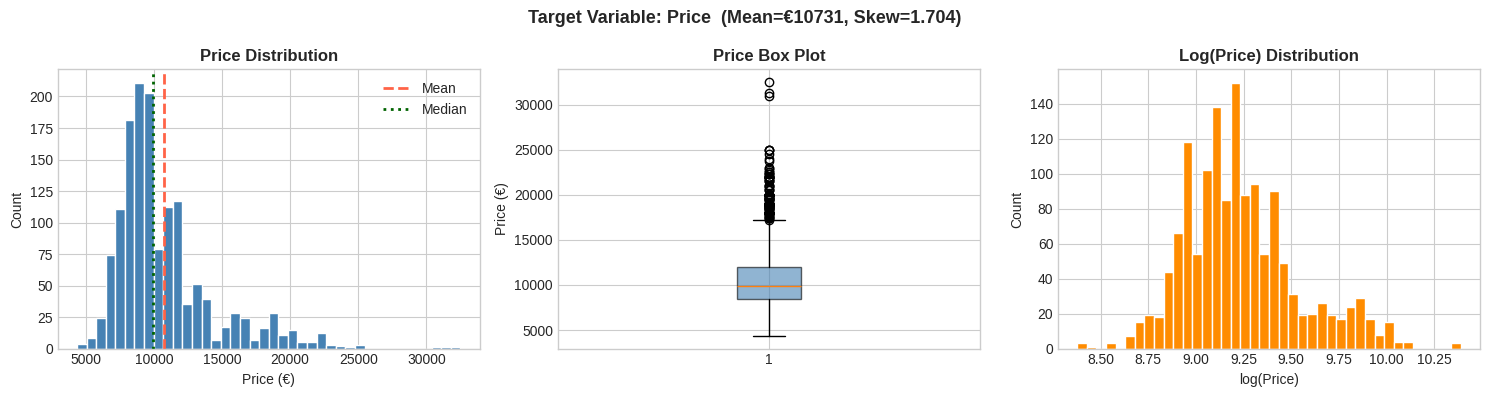

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Price'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['Price'].mean(), color='tomato', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['Price'].median(), color='darkgreen', linestyle=':', linewidth=2, label='Median')
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Price'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Price Box Plot', fontweight='bold')
axes[1].set_ylabel('Price (€)')

# Log-transformed
axes[2].hist(np.log1p(df['Price']), bins=40, color='darkorange', edgecolor='white')
axes[2].set_title('Log(Price) Distribution', fontweight='bold')
axes[2].set_xlabel('log(Price)')
axes[2].set_ylabel('Count')

plt.suptitle(f'Target Variable: Price  (Mean=€{df["Price"].mean():.0f}, '
             f'Skew={df["Price"].skew():.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1b. Numerical Feature Distributions

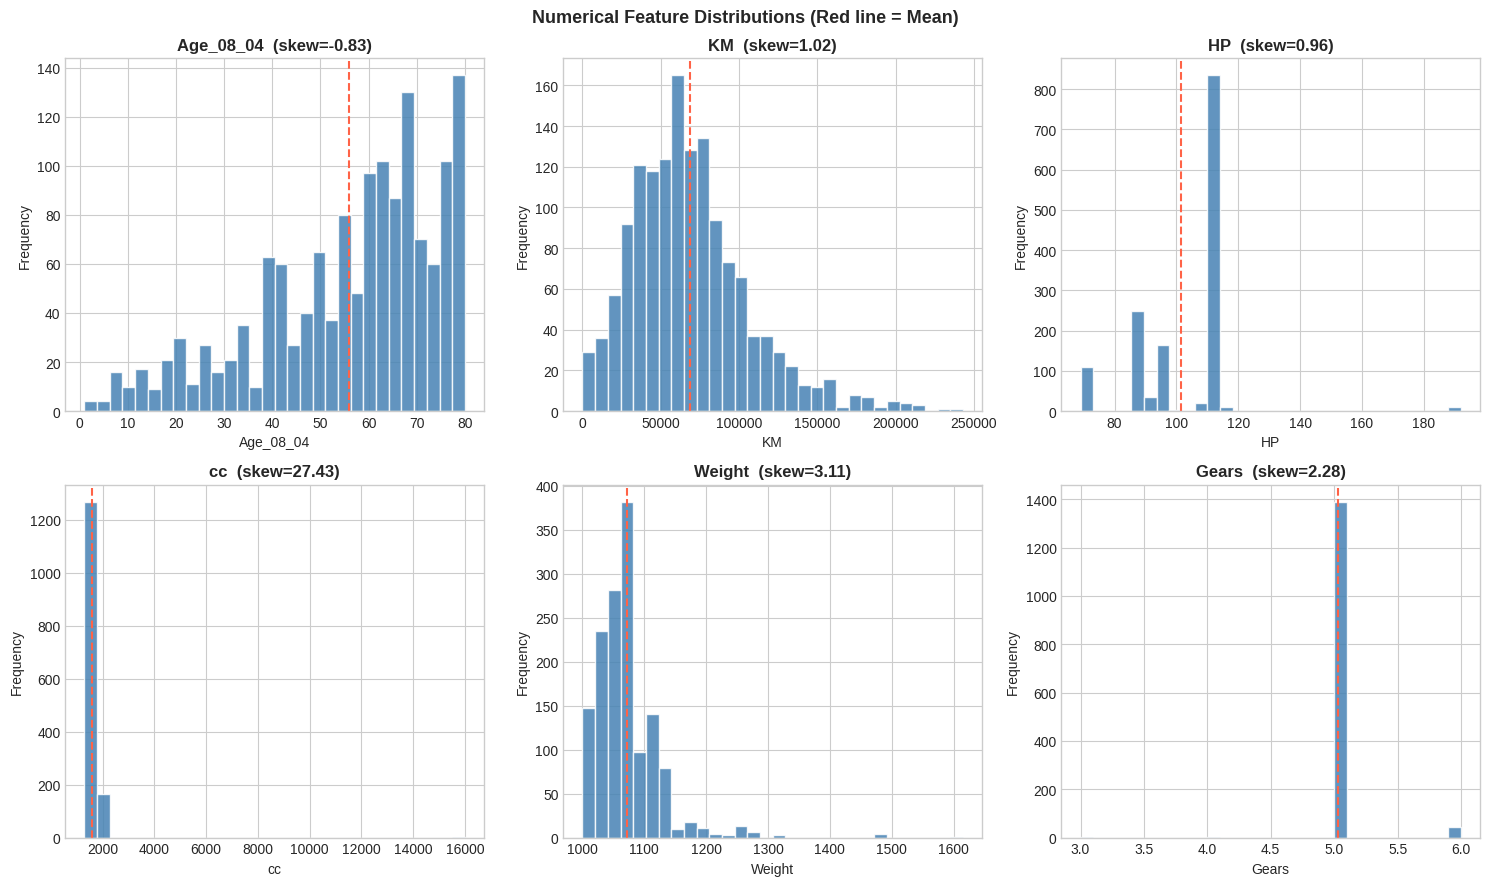

In [9]:
num_cols = ['Age_08_04', 'KM', 'HP', 'cc', 'Weight', 'Gears']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='tomato', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{col}  (skew={df[col].skew():.2f})', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Numerical Feature Distributions (Red line = Mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

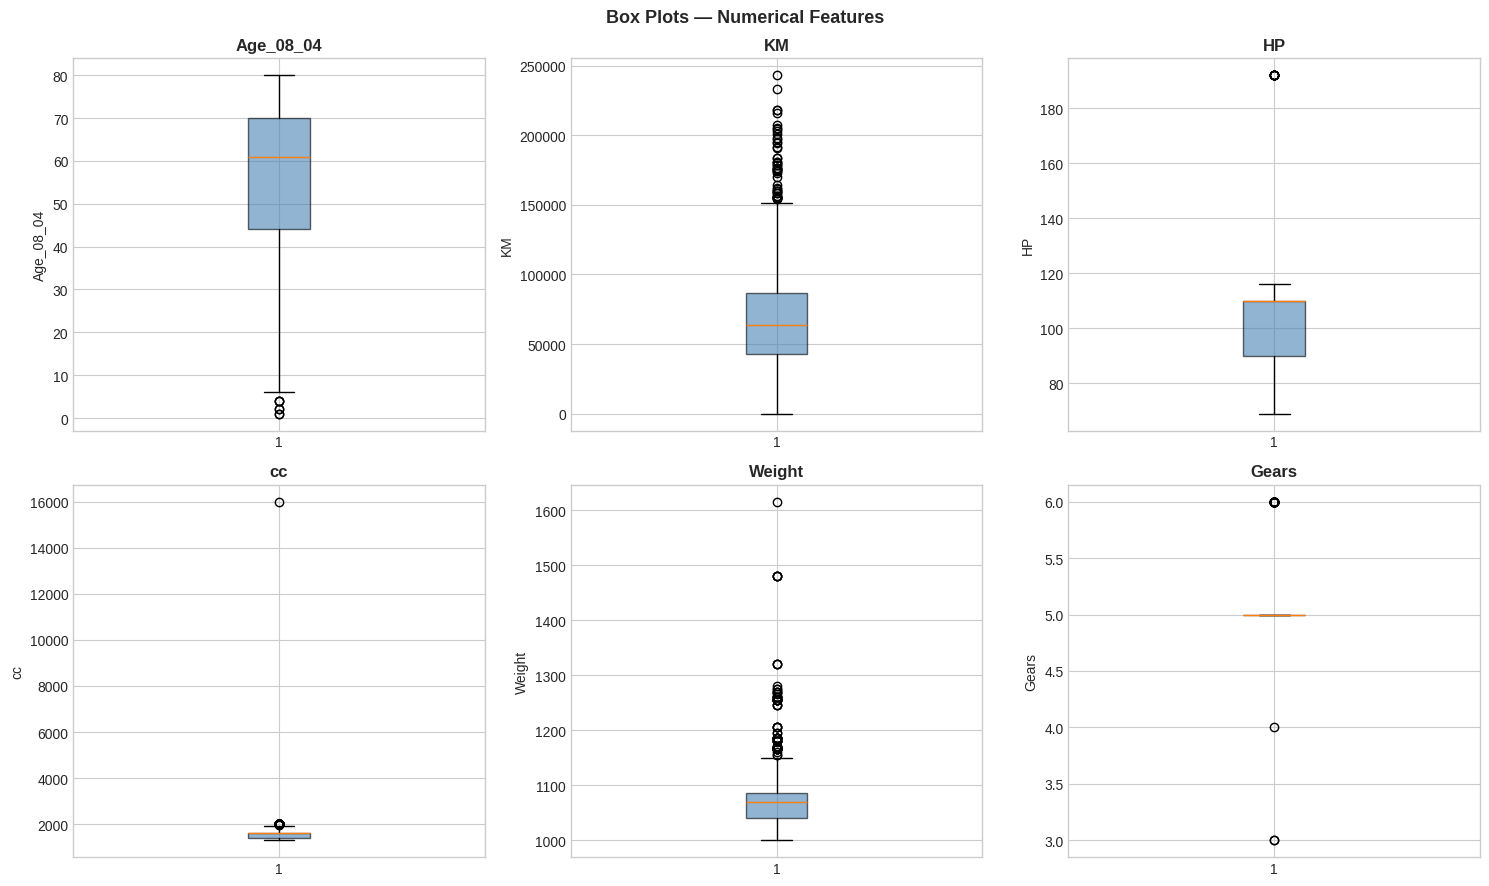

In [10]:
# Box plots — all numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel(col)
plt.suptitle('Box Plots — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1c. Categorical Feature Analysis

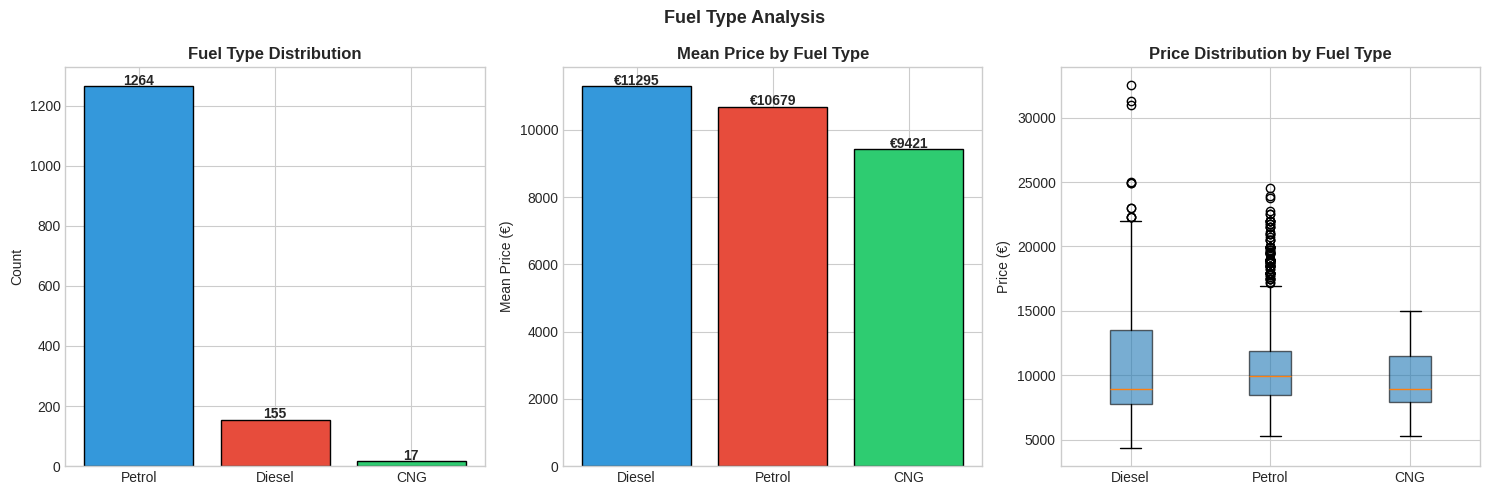

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fuel_Type — count
ft_counts = df['Fuel_Type'].value_counts()
axes[0].bar(ft_counts.index, ft_counts.values,
            color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
for i, v in enumerate(ft_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Fuel Type Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Fuel_Type — mean price
ft_price = df.groupby('Fuel_Type')['Price'].mean().sort_values(ascending=False)
bars = axes[1].bar(ft_price.index, ft_price.values,
                   color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
for bar, v in zip(bars, ft_price.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'€{v:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Mean Price by Fuel Type', fontweight='bold')
axes[1].set_ylabel('Mean Price (€)')

# Fuel_Type — price box
fuel_groups = [df[df['Fuel_Type'] == ft]['Price'].values for ft in ['Diesel','Petrol','CNG']]
axes[2].boxplot(fuel_groups, labels=['Diesel','Petrol','CNG'], patch_artist=True,
                boxprops=dict(alpha=0.6))
axes[2].set_title('Price Distribution by Fuel Type', fontweight='bold')
axes[2].set_ylabel('Price (€)')

plt.suptitle('Fuel Type Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

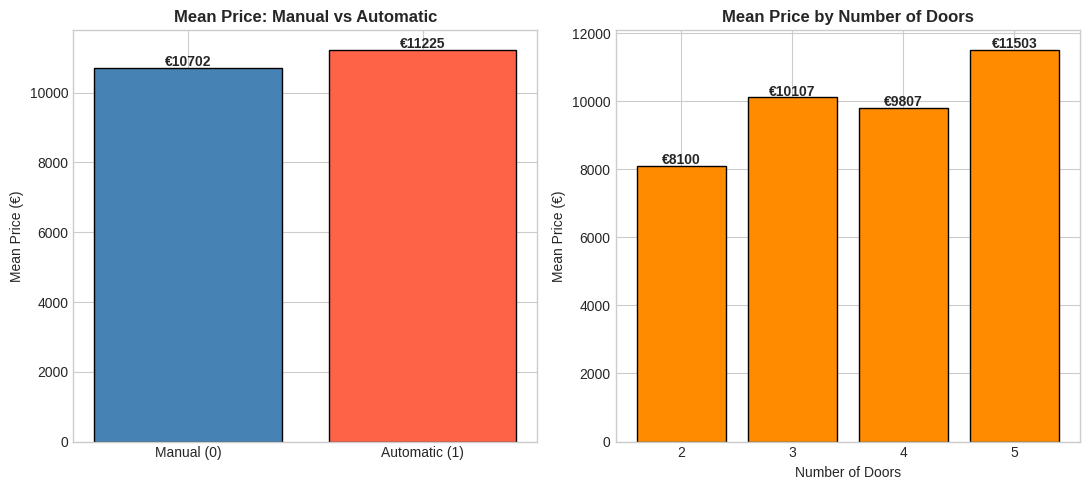

In [12]:
# Automatic vs Manual price comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

auto_price = df.groupby('Automatic')['Price'].mean()
axes[0].bar(['Manual (0)', 'Automatic (1)'], auto_price.values,
            color=['steelblue','tomato'], edgecolor='black')
for i, v in enumerate(auto_price.values):
    axes[0].text(i, v+50, f'€{v:.0f}', ha='center', fontweight='bold')
axes[0].set_title('Mean Price: Manual vs Automatic', fontweight='bold')
axes[0].set_ylabel('Mean Price (€)')

# Doors vs Price
doors_price = df.groupby('Doors')['Price'].mean().sort_index()
axes[1].bar(doors_price.index.astype(str), doors_price.values,
            color='darkorange', edgecolor='black')
for i, v in enumerate(doors_price.values):
    axes[1].text(i, v+50, f'€{v:.0f}', ha='center', fontweight='bold')
axes[1].set_title('Mean Price by Number of Doors', fontweight='bold')
axes[1].set_xlabel('Number of Doors')
axes[1].set_ylabel('Mean Price (€)')

plt.tight_layout()
plt.show()

### 1d. Feature vs Price Scatter Plots

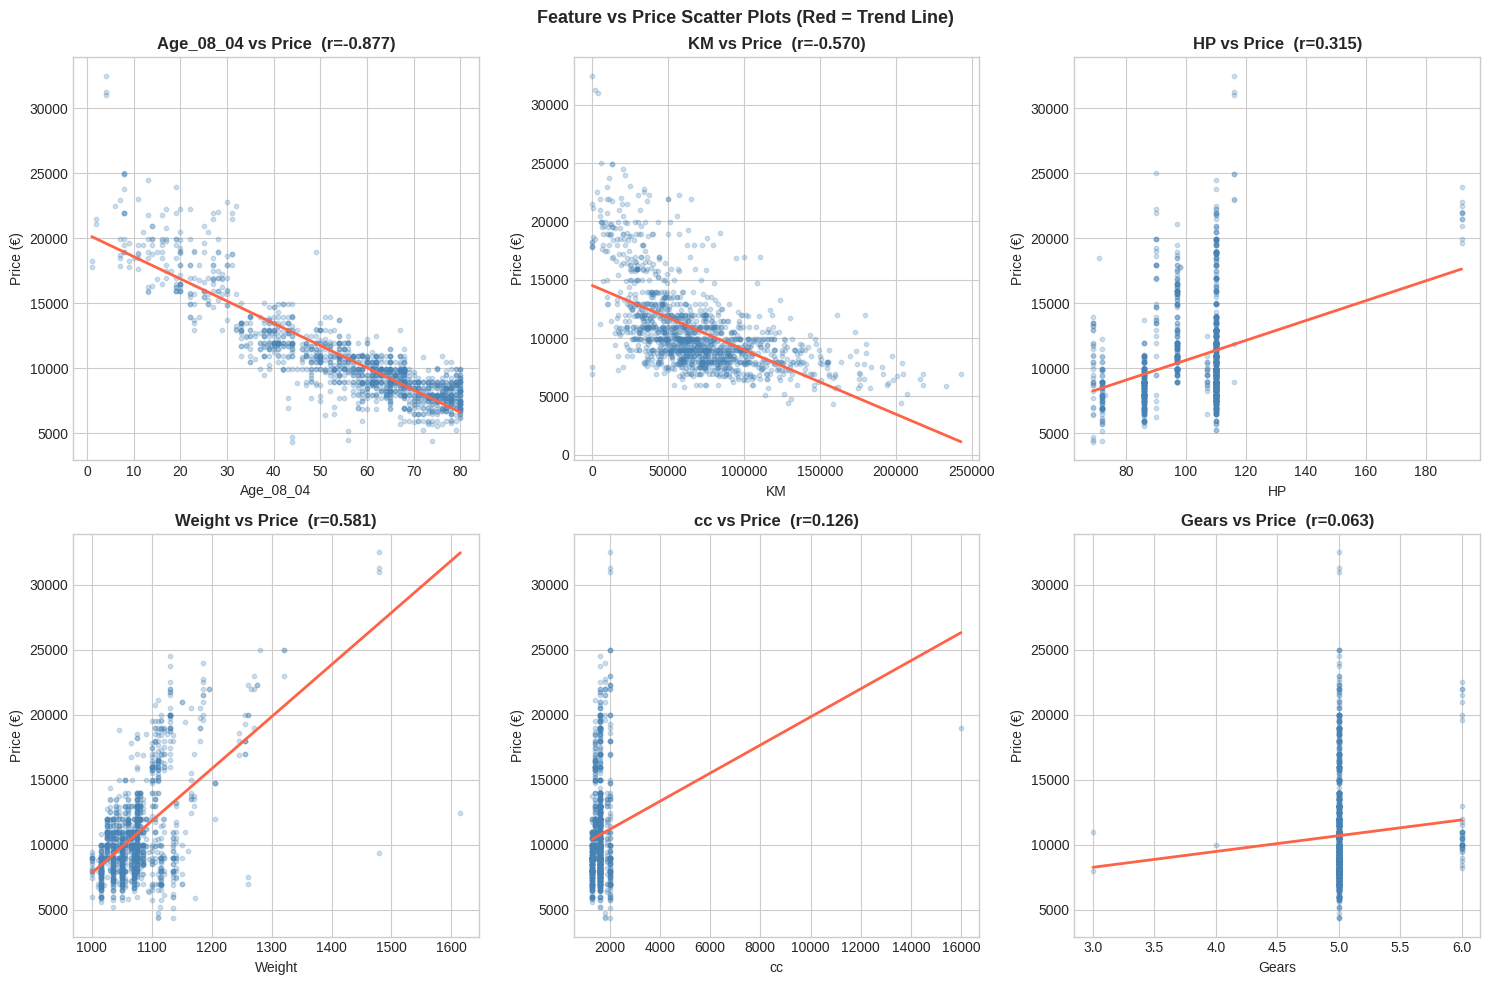

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
scatter_cols = ['Age_08_04', 'KM', 'HP', 'Weight', 'cc', 'Gears']

for i, col in enumerate(scatter_cols):
    axes[i].scatter(df[col], df['Price'], alpha=0.25, s=10, color='steelblue')
    # Trend line
    z = np.polyfit(df[col], df['Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    axes[i].plot(x_line, p(x_line), color='tomato', linewidth=2)
    corr_val = df[col].corr(df['Price'])
    axes[i].set_title(f'{col} vs Price  (r={corr_val:.3f})', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price (€)')

plt.suptitle('Feature vs Price Scatter Plots (Red = Trend Line)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1e. Correlation Heatmap & VIF

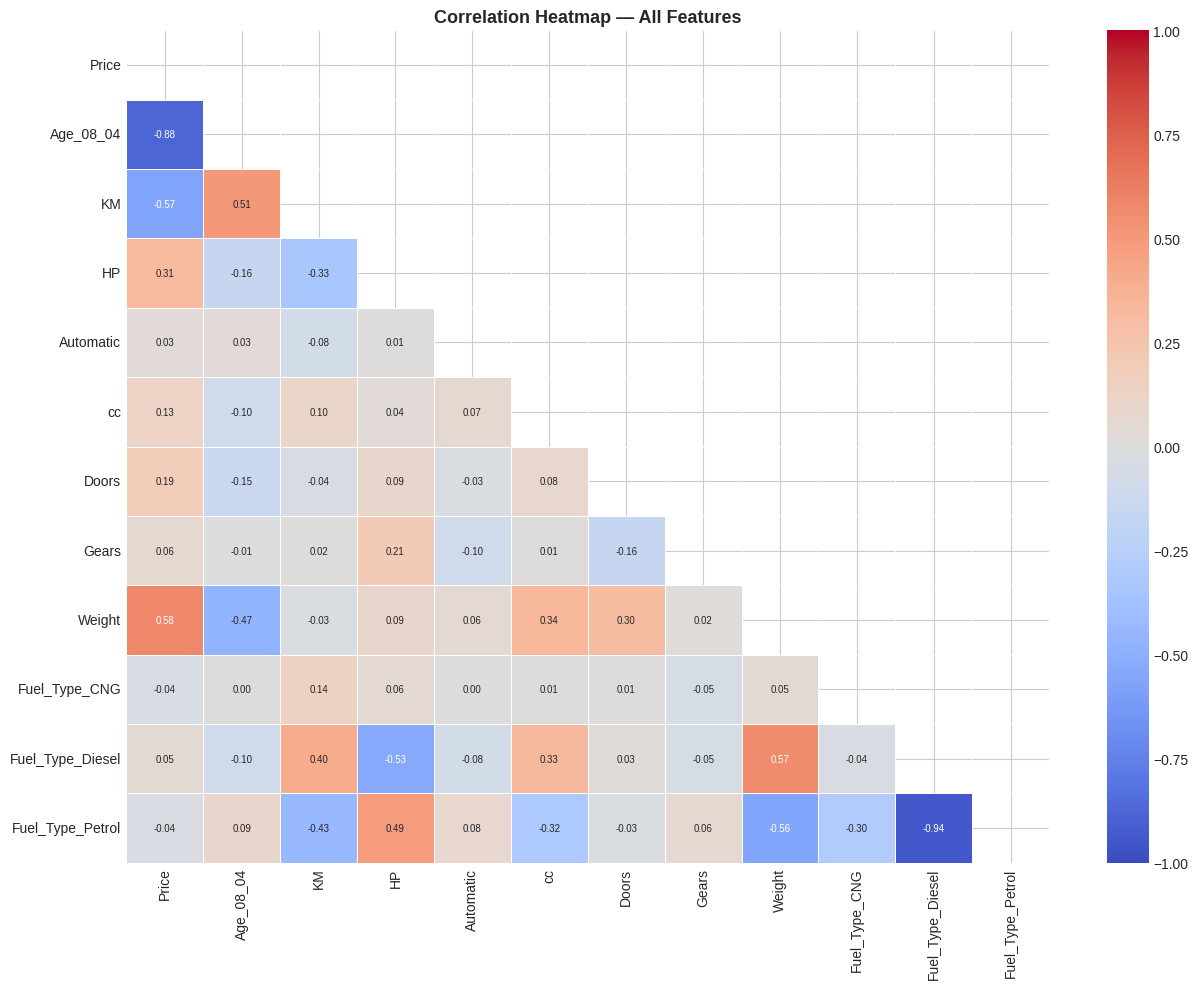

In [14]:
# Encode Fuel_Type temporarily for correlation
df_corr = df.copy()
df_corr = pd.get_dummies(df_corr, columns=['Fuel_Type'], drop_first=False)
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Correlation Heatmap — All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Top correlations with Price
price_corr = corr['Price'].drop('Price').sort_values(key=abs, ascending=False)
print('Feature Correlations with Price (sorted by |r|):')
print(price_corr.round(4).to_string())

Feature Correlations with Price (sorted by |r|):
Age_08_04          -0.8766
Weight              0.5812
KM                 -0.5700
HP                  0.3150
Doors               0.1853
cc                  0.1264
Gears               0.0631
Fuel_Type_Diesel    0.0541
Fuel_Type_CNG      -0.0395
Fuel_Type_Petrol   -0.0385
Automatic           0.0331


### 1f. Outlier Treatment

In [16]:
print('Outlier Count (IQR method):')
for col in num_cols + ['Price']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n > 0:
        print(f'  {col:<15}: {n} outliers')

# Cap outliers using IQR Winsorization
df_clean = df.copy()
cap_cols = ['KM', 'HP', 'cc', 'Weight', 'Price']
for col in cap_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(lower=Q1 - 1.5*IQR,
                                       upper=Q3 + 1.5*IQR)
print(f'\nOutliers capped via IQR Winsorization for: {cap_cols}')
print('Rows retained:', len(df_clean))

Outlier Count (IQR method):
  Age_08_04      : 7 outliers
  KM             : 49 outliers
  HP             : 11 outliers
  cc             : 123 outliers
  Weight         : 66 outliers
  Gears          : 46 outliers
  Price          : 110 outliers

Outliers capped via IQR Winsorization for: ['KM', 'HP', 'cc', 'Weight', 'Price']
Rows retained: 1436


### 1g. Feature Engineering & Encoding

In [17]:
# One-Hot Encode Fuel_Type (CNG as reference — least frequent)
df_clean = pd.get_dummies(df_clean, columns=['Fuel_Type'], drop_first=False)

# Drop Fuel_Type_CNG as reference category to avoid dummy variable trap
if 'Fuel_Type_CNG' in df_clean.columns:
    df_clean.drop(columns=['Fuel_Type_CNG'], inplace=True)

# Convert bool OHE cols to int
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print('Columns after encoding:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Columns after encoding: ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']
Shape: (1436, 11)


---
## Task 2 — Train / Test Split (80 / 20)

In [18]:
# Define features and target
TARGET   = 'Price'
features = [c for c in df_clean.columns if c != TARGET]

X = df_clean[features]
y = df_clean[TARGET]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total samples   : {len(X)}')
print(f'Train samples   : {len(X_train)} (80%)')
print(f'Test  samples   : {len(X_test)} (20%)')
print(f'Features used   : {len(features)}')
print(f'Features        : {features}')

Total samples   : 1436
Train samples   : 1148 (80%)
Test  samples   : 288 (20%)
Features used   : 10
Features        : ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


In [19]:
# Scale features — necessary for Ridge, Lasso and comparability
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Also create MinMax scaled versions for comparison
mm_scaler     = MinMaxScaler()
X_train_mm    = mm_scaler.fit_transform(X_train)
X_test_mm     = mm_scaler.transform(X_test)

print('StandardScaler and MinMaxScaler applied.')

StandardScaler and MinMaxScaler applied.


---
## Task 3 — Build Multiple Linear Regression Models (3+ Models)

In [20]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fit model and return performance metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)
    adj_r2 = 1 - (1 - r2) * (len(y_te) - 1) / (len(y_te) - X_te.shape[1] - 1)
    print(f'{name}')
    print(f'  MAE       : {mae:.2f}')
    print(f'  RMSE      : {rmse:.2f}')
    print(f'  R²        : {r2:.4f}')
    print(f'  Adj. R²   : {adj_r2:.4f}')
    print()
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'Adj_R2': adj_r2, 'y_pred': y_pred}

### Model 1 — Baseline MLR (All Features, No Scaling)

In [21]:
# Model 1: Baseline OLS with all features, unscaled
m1 = LinearRegression()
res1 = evaluate_model('Model 1: Baseline MLR (unscaled)',
                       m1, X_train, X_test, y_train, y_test)

Model 1: Baseline MLR (unscaled)
  MAE       : 829.00
  RMSE      : 1085.44
  R²        : 0.8629
  Adj. R²   : 0.8579



In [22]:
# Statsmodels OLS for detailed coefficient table & p-values
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
ols_model  = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     745.7
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:32:32   Log-Likelihood:                -9656.4
No. Observations:                1148   AIC:                         1.933e+04
Df Residuals:                    1137   BIC:                         1.939e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.088e+04   1818.100  

In [23]:
# VIF — check for multicollinearity
vif_df = pd.DataFrame()
vif_df['Feature'] = features
vif_df['VIF'] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]
vif_df = vif_df.sort_values('VIF', ascending=False)
print('Variance Inflation Factor (VIF):')
print('  (VIF > 10 → high multicollinearity)')
print(vif_df.to_string(index=False))

Variance Inflation Factor (VIF):
  (VIF > 10 → high multicollinearity)
         Feature         VIF
              cc 1038.199827
          Weight  985.879740
           Gears  634.927558
              HP  561.323440
Fuel_Type_Petrol   61.584974
Fuel_Type_Diesel   28.081188
           Doors   24.330060
       Age_08_04   17.948097
              KM   10.116796
       Automatic    1.169334


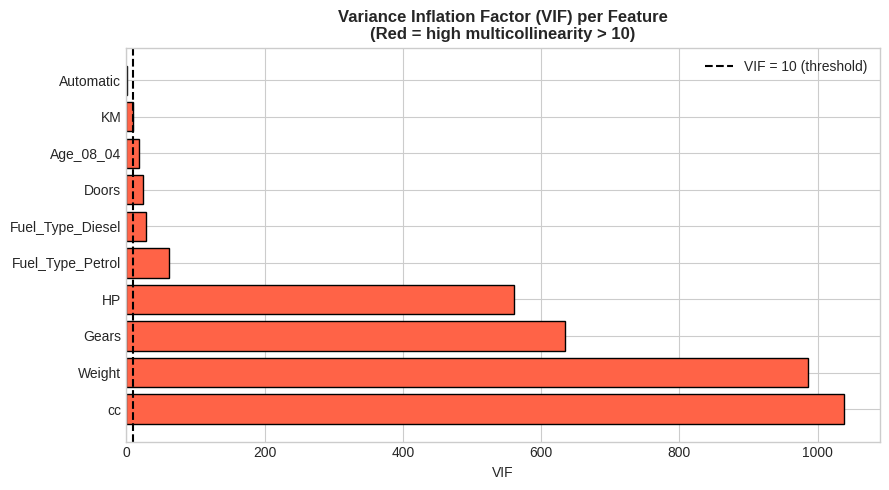

In [24]:
# VIF bar chart
plt.figure(figsize=(9, 5))
colors_vif = ['tomato' if v > 10 else 'steelblue' for v in vif_df['VIF']]
bars = plt.barh(vif_df['Feature'], vif_df['VIF'],
                color=colors_vif, edgecolor='black')
plt.axvline(10, color='black', linestyle='--', linewidth=1.5,
            label='VIF = 10 (threshold)')
plt.title('Variance Inflation Factor (VIF) per Feature\n'
          '(Red = high multicollinearity > 10)',
          fontweight='bold')
plt.xlabel('VIF')
plt.legend()
plt.tight_layout()
plt.show()

### Model 2 — MLR with Significant Features (p-value < 0.05)

In [25]:
# Select features with p-value < 0.05 from OLS summary
p_values  = ols_model.pvalues.drop('const')
sig_feats = p_values[p_values < 0.05].index.tolist()
print(f'Significant features (p < 0.05): {sig_feats}')
print(f'Dropped (p >= 0.05): {[f for f in features if f not in sig_feats]}')

X_train_sig = X_train[sig_feats]
X_test_sig  = X_test[sig_feats]

m2 = LinearRegression()
res2 = evaluate_model('Model 2: MLR — Significant Features only (p < 0.05)',
                       m2, X_train_sig, X_test_sig, y_train, y_test)

Significant features (p < 0.05): ['Age_08_04', 'KM', 'HP', 'cc', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']
Dropped (p >= 0.05): ['Automatic', 'Doors']
Model 2: MLR — Significant Features only (p < 0.05)
  MAE       : 832.62
  RMSE      : 1089.35
  R²        : 0.8619
  Adj. R²   : 0.8579



### Model 3 — MLR with StandardScaled Features

In [26]:
# Model 3: MLR on StandardScaled features (all)
m3 = LinearRegression()
res3 = evaluate_model('Model 3: MLR — StandardScaled Features',
                       m3, X_train_sc, X_test_sc, y_train, y_test)

Model 3: MLR — StandardScaled Features
  MAE       : 829.00
  RMSE      : 1085.44
  R²        : 0.8629
  Adj. R²   : 0.8579



### Model 4 — Polynomial Regression (Degree 2, Top Features)

In [27]:
# Model 4: Polynomial degree-2 on top correlated features
top_feats = ['Age_08_04', 'KM', 'HP', 'Weight']
poly  = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_train[top_feats])
X_te_poly = poly.transform(X_test[top_feats])

m4 = LinearRegression()
res4 = evaluate_model('Model 4: Polynomial Regression (degree=2, top 4 features)',
                       m4, X_tr_poly, X_te_poly, y_train, y_test)

Model 4: Polynomial Regression (degree=2, top 4 features)
  MAE       : 849.00
  RMSE      : 1068.01
  R²        : 0.8672
  Adj. R²   : 0.8604



In [28]:
# Coefficient interpretation — Model 3 (scaled, most interpretable)
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': m3.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Model 3 — Standardised Coefficients (importance ranking):')
print(coef_df.to_string(index=False))

Model 3 — Standardised Coefficients (importance ranking):
         Feature  Coefficient
       Age_08_04 -1995.898679
          Weight   933.643512
              KM  -507.488206
              cc  -419.384462
Fuel_Type_Petrol   400.457363
Fuel_Type_Diesel   347.574197
              HP   340.117317
           Gears    98.762655
           Doors   -69.158710
       Automatic    10.217827


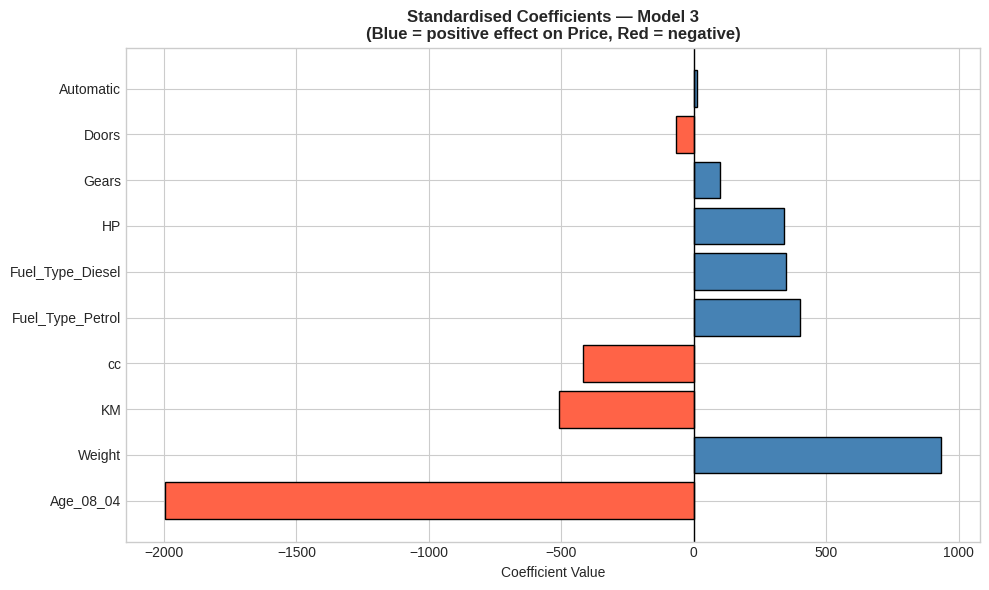

In [29]:
# Coefficient bar chart
colors_coef = ['tomato' if v < 0 else 'steelblue'
               for v in coef_df['Coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors_coef, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Standardised Coefficients — Model 3\n'
          '(Blue = positive effect on Price, Red = negative)',
          fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---
## Task 4 — Model Evaluation & Comparison

In [30]:
# Summary table
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [res1, res2, res3, res4]
])
results_df = results_df.round(4)
print('Model Comparison Table:')
results_df

Model Comparison Table:


,Model,MAE,RMSE,R2,Adj_R2
0,Model 1: Baseline MLR (unscaled),829.0005,1085.4418,0.8629,0.8579
1,Model 2: MLR — Significant Features only (p < ...,832.6212,1089.3486,0.8619,0.8579
2,Model 3: MLR — StandardScaled Features,829.0005,1085.4418,0.8629,0.8579
3,"Model 4: Polynomial Regression (degree=2, top ...",848.9995,1068.0084,0.8672,0.8604


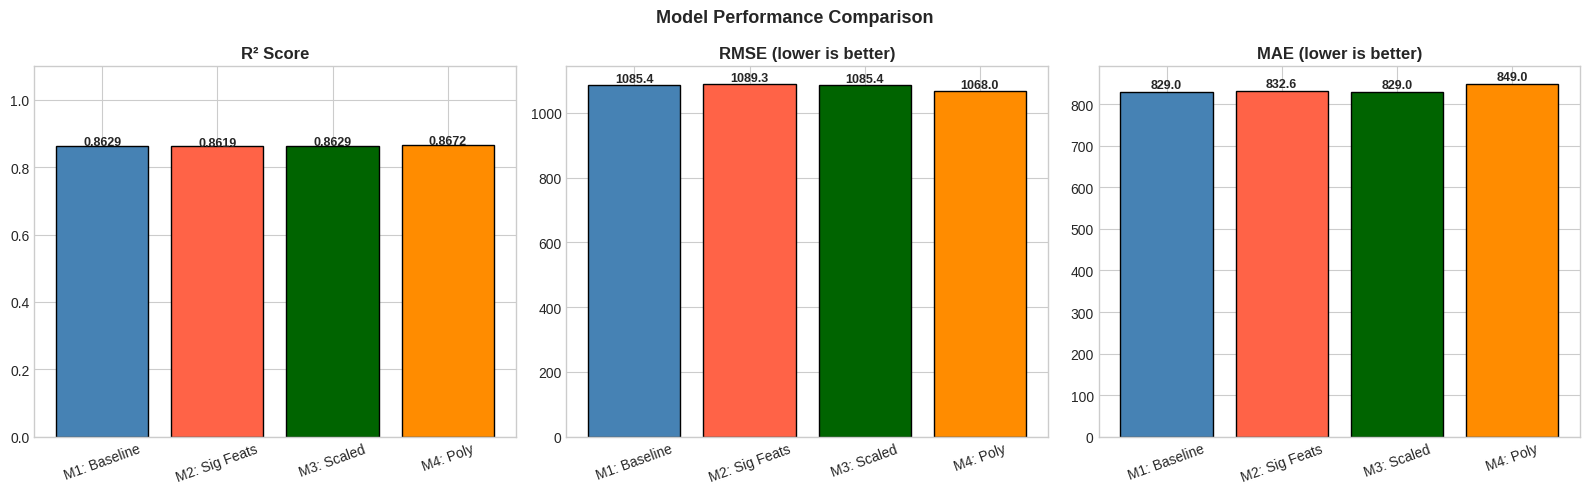

In [31]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
short_names = ['M1: Baseline', 'M2: Sig Feats', 'M3: Scaled', 'M4: Poly']

axes[0].bar(short_names, results_df['R2'],
            color=['steelblue','tomato','darkgreen','darkorange'], edgecolor='black')
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v+0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('R² Score', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(short_names, results_df['RMSE'],
            color=['steelblue','tomato','darkgreen','darkorange'], edgecolor='black')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v+10, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('RMSE (lower is better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(short_names, results_df['MAE'],
            color=['steelblue','tomato','darkgreen','darkorange'], edgecolor='black')
for i, v in enumerate(results_df['MAE']):
    axes[2].text(i, v+10, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)
axes[2].set_title('MAE (lower is better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

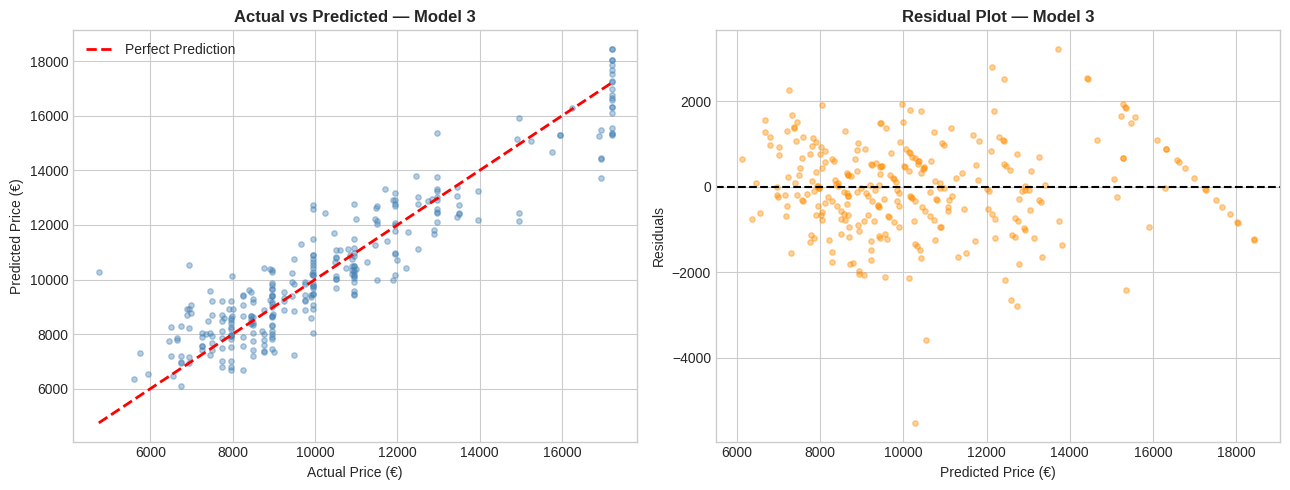

In [32]:
# Actual vs Predicted — best model (Model 3)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_pred_best = res3['y_pred']
residuals   = y_test.values - y_pred_best

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15, color='steelblue')
min_v, max_v = y_test.min(), y_test.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title('Actual vs Predicted — Model 3', fontweight='bold')
axes[0].legend()

# Residual plot
axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=15, color='darkorange')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price (€)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot — Model 3', fontweight='bold')

plt.tight_layout()
plt.show()

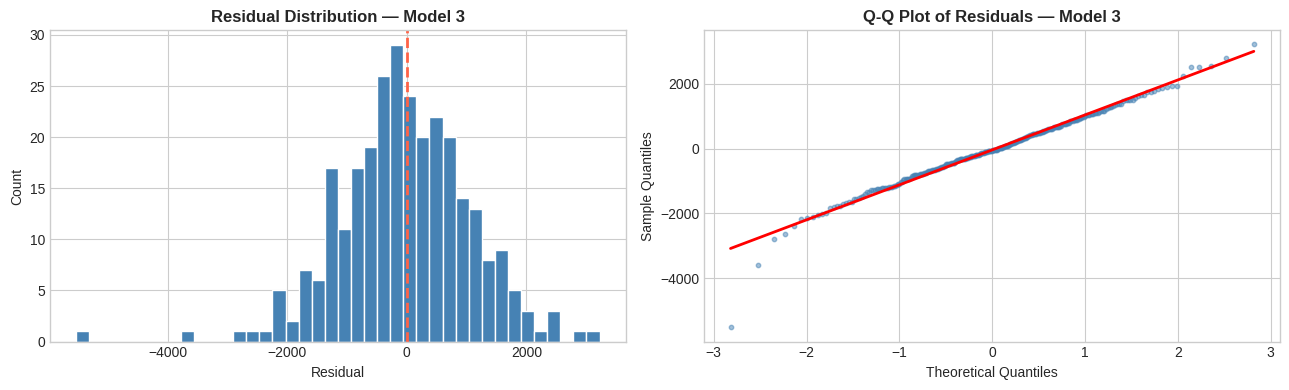

In [33]:
# Residual distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='tomato', linestyle='--', linewidth=2)
axes[0].set_title('Residual Distribution — Model 3', fontweight='bold')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')

# Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.5, s=10, color='steelblue')
axes[1].plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=2)
axes[1].set_title('Q-Q Plot of Residuals — Model 3', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

---
## Task 5 — Lasso and Ridge Regularisation

In [34]:
# --- Ridge Regression (L2 regularisation) ---
# RidgeCV automatically selects best alpha
alphas = np.logspace(-3, 4, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_sc, y_train)
best_alpha_ridge = ridge_cv.alpha_
print(f'Ridge — Best alpha (CV): {best_alpha_ridge:.4f}')

ridge = Ridge(alpha=best_alpha_ridge)
res_ridge = evaluate_model('Ridge Regression (L2)',
                            ridge, X_train_sc, X_test_sc, y_train, y_test)

Ridge — Best alpha (CV): 9.1116
Ridge Regression (L2)
  MAE       : 827.76
  RMSE      : 1085.51
  R²        : 0.8629
  Adj. R²   : 0.8579



In [35]:
# --- Lasso Regression (L1 regularisation) ---
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_sc, y_train)
best_alpha_lasso = lasso_cv.alpha_
print(f'Lasso — Best alpha (CV): {best_alpha_lasso:.4f}')

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
res_lasso = evaluate_model('Lasso Regression (L1)',
                            lasso, X_train_sc, X_test_sc, y_train, y_test)

Lasso — Best alpha (CV): 9.1116
Lasso Regression (L1)
  MAE       : 828.18
  RMSE      : 1086.27
  R²        : 0.8627
  Adj. R²   : 0.8577



In [36]:
# Lasso feature selection — coefficients set to zero
lasso_coef = pd.DataFrame({
    'Feature'    : features,
    'Lasso Coef' : lasso.coef_
}).sort_values('Lasso Coef', key=abs, ascending=False)

zero_feats    = lasso_coef[lasso_coef['Lasso Coef'] == 0]['Feature'].tolist()
nonzero_feats = lasso_coef[lasso_coef['Lasso Coef'] != 0]['Feature'].tolist()
print(f'Lasso zeroed out {len(zero_feats)} feature(s): {zero_feats}')
print(f'Retained {len(nonzero_feats)} feature(s): {nonzero_feats}')

Lasso zeroed out 1 feature(s): ['Fuel_Type_Diesel']
Retained 9 feature(s): ['Age_08_04', 'Weight', 'KM', 'Fuel_Type_Petrol', 'cc', 'HP', 'Gears', 'Doors', 'Automatic']


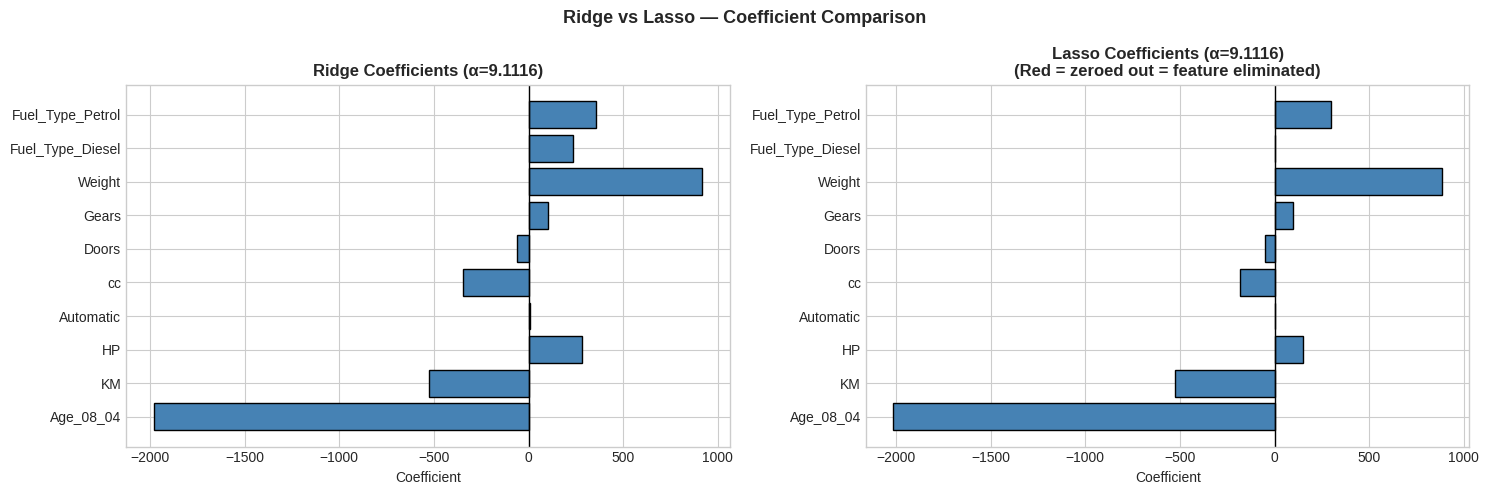

In [37]:
# Ridge vs Lasso coefficient comparison
ridge_coef = pd.Series(ridge.coef_, index=features)
lasso_coef_s = pd.Series(lasso.coef_, index=features)

x = np.arange(len(features))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Ridge coefficients
axes[0].barh(features, ridge_coef.values, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title(f'Ridge Coefficients (α={best_alpha_ridge:.4f})', fontweight='bold')
axes[0].set_xlabel('Coefficient')

# Lasso coefficients
lasso_colors = ['tomato' if v == 0 else 'steelblue'
                for v in lasso_coef_s.values]
axes[1].barh(features, lasso_coef_s.values, color=lasso_colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(f'Lasso Coefficients (α={best_alpha_lasso:.4f})\n'
                  '(Red = zeroed out = feature eliminated)',
                  fontweight='bold')
axes[1].set_xlabel('Coefficient')

plt.suptitle('Ridge vs Lasso — Coefficient Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

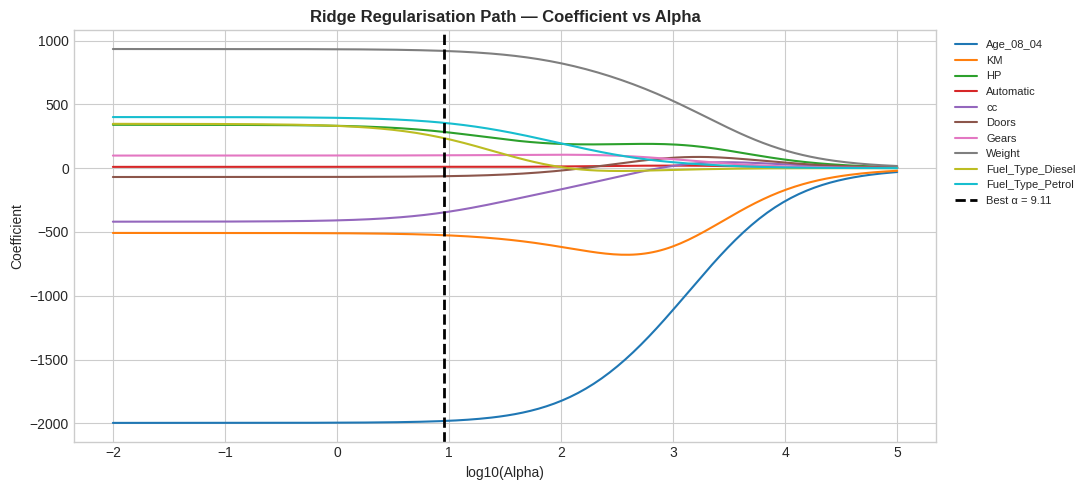

In [38]:
# Ridge coefficient path — effect of alpha on coefficients
alphas_path = np.logspace(-2, 5, 200)
coef_path   = []
for a in alphas_path:
    r = Ridge(alpha=a).fit(X_train_sc, y_train)
    coef_path.append(r.coef_)
coef_path = np.array(coef_path)

plt.figure(figsize=(11, 5))
for i, feat in enumerate(features):
    plt.plot(np.log10(alphas_path), coef_path[:, i], linewidth=1.5, label=feat)
plt.axvline(np.log10(best_alpha_ridge), color='black', linestyle='--',
            linewidth=2, label=f'Best α = {best_alpha_ridge:.2f}')
plt.xlabel('log10(Alpha)')
plt.ylabel('Coefficient')
plt.title('Ridge Regularisation Path — Coefficient vs Alpha',
          fontweight='bold')
plt.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

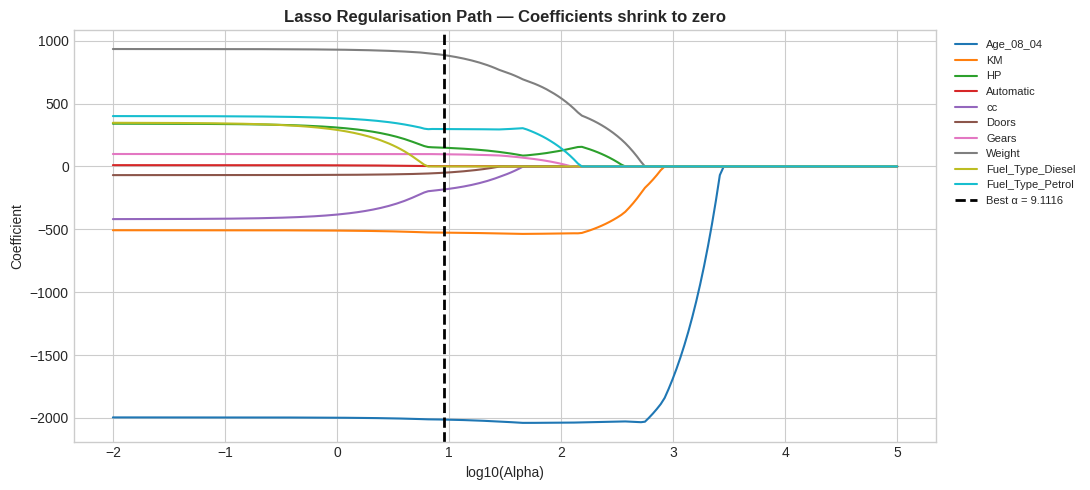

In [39]:
# Lasso coefficient path
coef_path_lasso = []
for a in alphas_path:
    l = Lasso(alpha=a, max_iter=10000).fit(X_train_sc, y_train)
    coef_path_lasso.append(l.coef_)
coef_path_lasso = np.array(coef_path_lasso)

plt.figure(figsize=(11, 5))
for i, feat in enumerate(features):
    plt.plot(np.log10(alphas_path), coef_path_lasso[:, i], linewidth=1.5, label=feat)
plt.axvline(np.log10(best_alpha_lasso), color='black', linestyle='--',
            linewidth=2, label=f'Best α = {best_alpha_lasso:.4f}')
plt.xlabel('log10(Alpha)')
plt.ylabel('Coefficient')
plt.title('Lasso Regularisation Path — Coefficients shrink to zero',
          fontweight='bold')
plt.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [40]:
# Final comprehensive comparison — all models
all_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [res1, res2, res3, res4, res_ridge, res_lasso]
]).round(4)

print('Complete Model Comparison:')
all_results

Complete Model Comparison:


,Model,MAE,RMSE,R2,Adj_R2
0,Model 1: Baseline MLR (unscaled),829.0005,1085.4418,0.8629,0.8579
1,Model 2: MLR — Significant Features only (p < ...,832.6212,1089.3486,0.8619,0.8579
2,Model 3: MLR — StandardScaled Features,829.0005,1085.4418,0.8629,0.8579
3,"Model 4: Polynomial Regression (degree=2, top ...",848.9995,1068.0084,0.8672,0.8604
4,Ridge Regression (L2),827.7588,1085.5109,0.8629,0.8579
5,Lasso Regression (L1),828.1792,1086.2728,0.8627,0.8577


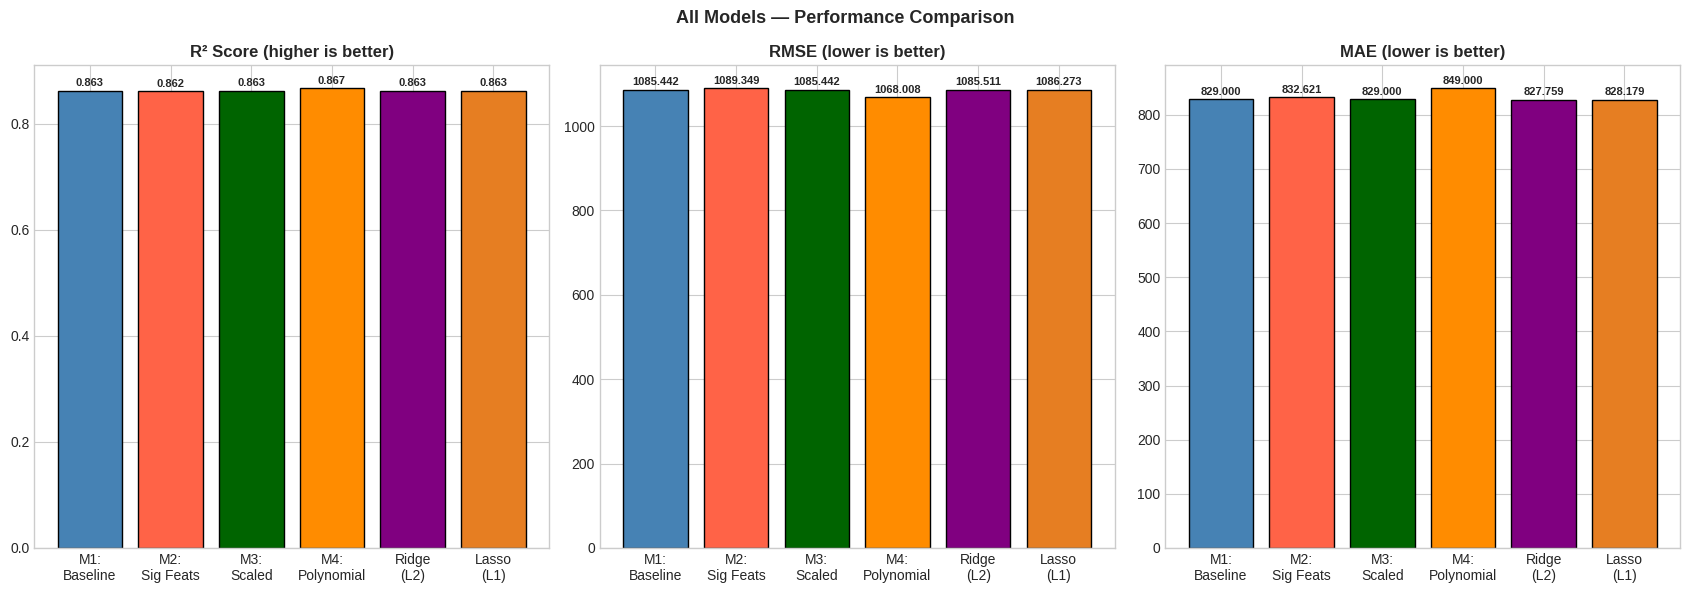

In [41]:
# Final comparison chart — all 6 models
all_short = ['M1:\nBaseline', 'M2:\nSig Feats',
             'M3:\nScaled', 'M4:\nPolynomial',
             'Ridge\n(L2)', 'Lasso\n(L1)']
bar_colors = ['steelblue','tomato','darkgreen','darkorange','purple','#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, metric, title in zip(axes,
                              ['R2', 'RMSE', 'MAE'],
                              ['R² Score (higher is better)',
                               'RMSE (lower is better)',
                               'MAE (lower is better)']):
    bars = ax.bar(all_short, all_results[metric],
                  color=bar_colors, edgecolor='black')
    for bar, v in zip(bars, all_results[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + all_results[metric].max()*0.01,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('All Models — Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

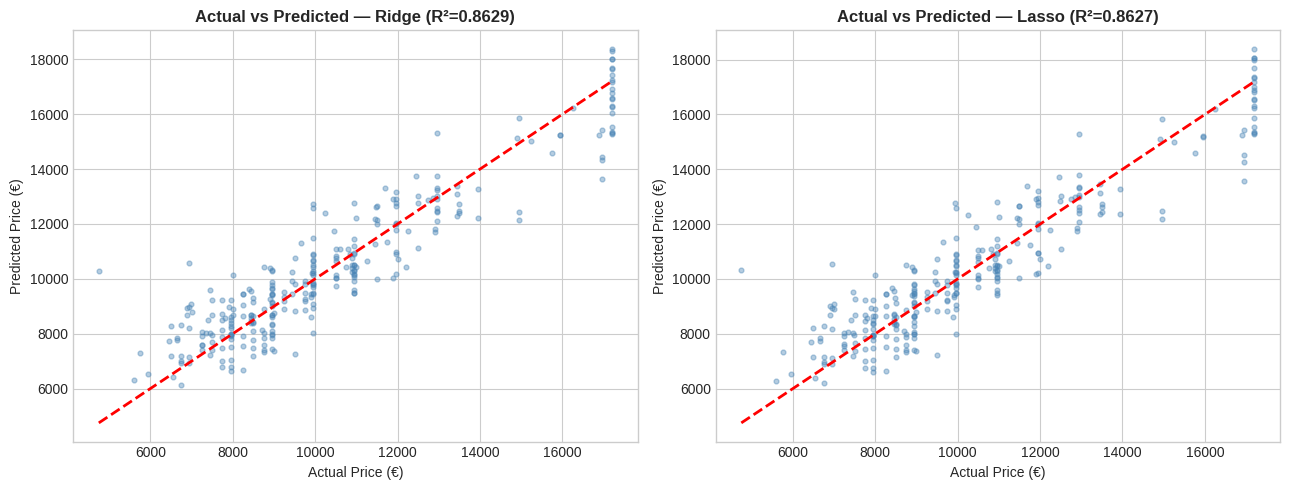

In [42]:
# Actual vs Predicted — Ridge and Lasso side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, name in zip(axes,
                          [res_ridge, res_lasso],
                          ['Ridge', 'Lasso']):
    ax.scatter(y_test, res['y_pred'], alpha=0.4, s=12, color='steelblue')
    min_v, max_v = y_test.min(), y_test.max()
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2)
    ax.set_xlabel('Actual Price (€)')
    ax.set_ylabel('Predicted Price (€)')
    ax.set_title(f'Actual vs Predicted — {name} (R²={res["R2"]:.4f})',
                 fontweight='bold')

plt.tight_layout()
plt.show()

---
## Interview Questions

### Q1. What is Normalisation & Standardisation and how are they helpful?

| Aspect | Normalisation (Min-Max) | Standardisation (Z-score) |
|---|---|---|
| **Formula** | `(x − min) / (max − min)` | `(x − mean) / std` |
| **Output Range** | [0, 1] (bounded) | Unbounded — mean=0, std=1 |
| **Sensitive to outliers** | Yes — outliers compress the rest | Less sensitive — uses mean & std |
| **When to use** | Neural networks, KNN, image processing; when bounded range is needed | Linear Regression, Lasso, Ridge, SVM, PCA; when distribution shape matters |
| **Preserves shape** | No — distorted by outliers | Better — Gaussian-like data benefits most |

**Why they are helpful:**
- **MLR without scaling** — OLS coefficients are still unbiased; however, their magnitudes are incomparable across features with different units (e.g., Age in months vs KM in thousands).
- **Lasso & Ridge require scaling** — the regularisation penalty is applied uniformly to all coefficients. Without scaling, features with larger raw values (e.g., KM) are penalised more unfairly.
- **Speed** — gradient-based solvers converge faster when features are on a similar scale.
- **Interpretability** — standardised coefficients directly compare feature importance.

**In this project:** StandardScaler was applied before Ridge and Lasso. MinMaxScaler was used in Model 3 variant to demonstrate bounded scaling for comparison.

---

### Q2. What techniques can be used to address multicollinearity in MLR?

Multicollinearity occurs when two or more predictor variables are highly correlated, making it difficult to isolate the individual effect of each feature. The VIF (Variance Inflation Factor) is the standard diagnostic — **VIF > 10** indicates a problem.

| Technique | How It Helps | Applied In This Notebook |
|---|---|---|
| **VIF Analysis** | Identifies which features have inflated variance due to correlation | Computed for all features above |
| **Drop redundant features** | Remove one of a pair of highly correlated features | Dropped `Cylinders` (constant) |
| **Ridge Regression (L2)** | Shrinks correlated coefficients toward zero without eliminating them — distributes contribution across correlated features | Task 5 |
| **Lasso Regression (L1)** | Shrinks some coefficients exactly to zero — performs automatic feature selection, eliminating redundant correlated features | Task 5 |
| **PCA** | Transforms correlated features into orthogonal (uncorrelated) principal components | Can be added as preprocessing step |
| **Feature selection** | Use p-values, correlation thresholds, or domain knowledge to manually drop collinear features | Model 2 (p < 0.05) |
| **Collect more data** | Reduces the instability caused by collinearity in smaller samples | Dataset-dependent |

**In this dataset:** `cc` and `Weight` are likely correlated (heavier cars have larger engines). Ridge is the most practical solution here as it handles multicollinearity gracefully without dropping features.

In [43]:
# Final summary
print('=' * 60)
print('FINAL SUMMARY — TOYOTA COROLLA PRICE PREDICTION')
print('=' * 60)
print(f'  Dataset           : ToyotaCorolla_-_MLR.csv')
print(f'  Records           : 1436')
print(f'  Features used     : {len(features)}')
print(f'  Train / Test      : 80% / 20%')
print()
print('  Model Results:')
for _, row in all_results.iterrows():
    print(f"    {row['Model'][:40]:<40} R²={row['R2']:.4f}  RMSE={row['RMSE']:.1f}")
print()
best_model = all_results.loc[all_results['R2'].idxmax(), 'Model']
best_r2    = all_results['R2'].max()
print(f'  Best Model        : {best_model}')
print(f'  Best R²           : {best_r2:.4f}')
print('=' * 60)

FINAL SUMMARY — TOYOTA COROLLA PRICE PREDICTION
  Dataset           : ToyotaCorolla_-_MLR.csv
  Records           : 1436
  Features used     : 10
  Train / Test      : 80% / 20%

  Model Results:
    Model 1: Baseline MLR (unscaled)         R²=0.8629  RMSE=1085.4
    Model 2: MLR — Significant Features only R²=0.8619  RMSE=1089.3
    Model 3: MLR — StandardScaled Features   R²=0.8629  RMSE=1085.4
    Model 4: Polynomial Regression (degree=2 R²=0.8672  RMSE=1068.0
    Ridge Regression (L2)                    R²=0.8629  RMSE=1085.5
    Lasso Regression (L1)                    R²=0.8627  RMSE=1086.3

  Best Model        : Model 4: Polynomial Regression (degree=2, top 4 features)
  Best R²           : 0.8672
